Analytic Variational Bayes. Inferring a single Gaussian
=====================

This notebook implements the example from section 3 of the FMRIB tutorial on Variational Bayes ("Inferring a single Gaussian").

We assume we have data drawn from a Gaussian distribution with true mean $\mu$ and true precision $\beta$:

$$
P(y_n | \mu, \beta) = \frac{\sqrt{\beta}}{\sqrt{2\pi}} \exp{-\frac{\beta}{2} (y_n - \mu)^2}
$$

One interpretation of this is that our data consists of repeated measurements of a fixed value ($\mu$) combined with Gaussian noise with standard deviation $\frac{1}{\sqrt{\beta}}$.

Here's how we can generate some sample data from this model in Python:

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
# Ground truth parameters
# We infer the precision, BETA, but it is useful to
# derive the variance and standard deviation from it
MU_TRUTH = 42
BETA_TRUTH = 0.5
VAR_TRUTH = 1/BETA_TRUTH
STD_TRUTH = np.sqrt(VAR_TRUTH)

# Observed data samples are generated by Numpy from the ground truth
# Gaussian distribution. Reducing the number of samples should make
# the inference less 'confident' - i.e. the output variances for
# MU and BETA will increase
N = 100
DATA = np.random.normal(MU_TRUTH, STD_TRUTH, [N])
print("Data samples are:")
print(DATA)

Data samples are:
[43.41911751 40.69178063 42.74090702 42.55103541 43.15653372 41.65713786
 41.71417727 45.16070931 40.95982049 40.77952433 42.72885363 42.03483788
 42.28420613 41.46869252 40.47580283 43.68536908 42.35346079 42.54966943
 41.09367393 43.3638101  41.49372331 40.22526017 42.49774999 41.09053758
 44.23615508 43.06205844 41.85859216 40.7088889  41.44153904 40.64667995
 43.08348678 39.91241784 44.42803918 39.94483233 43.12311342 40.83787294
 41.36568485 43.48181792 42.14480659 41.48420409 42.16978633 42.20175526
 43.59238722 42.0782277  43.92885674 41.97898037 43.2796148  42.35689356
 41.56398686 43.28363134 40.30690766 42.16898858 42.16338662 42.09654785
 43.09176927 42.72269848 41.91105494 41.27257127 43.17927119 43.46452752
 43.38219398 40.64036154 42.45737889 41.78954707 40.7681769  43.12942178
 42.51145048 44.1885338  43.46764724 40.5996107  42.23132578 41.3584144
 39.82437577 42.48587537 41.05112391 42.77837488 41.31185848 43.30881455
 42.5237036  44.88507678 41.385465

In the 'signal + noise' interpretation we can view this as noisy measurements (red crosses) of a constant signal (green line):

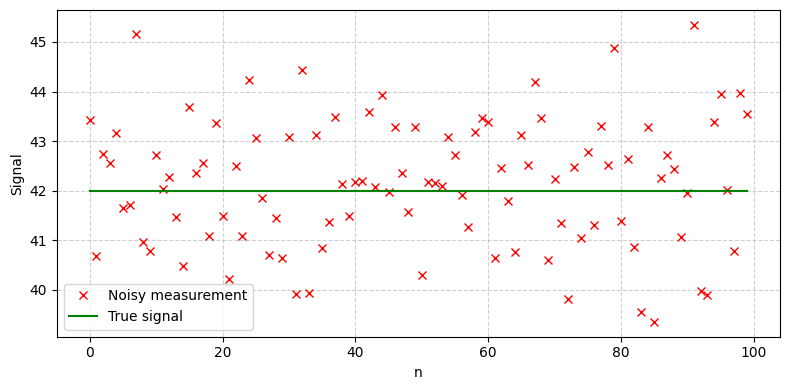

In [2]:
plt.figure(figsize=(8,4))
plt.xlabel("n")
plt.ylabel("Signal")
plt.plot(DATA, "rx", label="Noisy measurement")
plt.plot([MU_TRUTH] * N, "g", label="True signal")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In Variational Bayes we make the approximation that the posterior is factorised with respect to these two parameters:

$$q(\mu, \beta) = q(\mu)q(\beta)$$

Generally it is a requirement for the analytic formulation of Variational Bayes that the 'noise' and 'signal' parameters are factorised. In more complex examples where there is more than one 'signal' parameter (e.g. we are inferring the parameters of a complex nonlinear model), a combined distribution may be used for the multiple signal parameters, however the noise must still be factorised.

Another requirement for analytic VB is the choice of 'conjugate' distributions for the priors $P(\mu)$, $P(\beta)$, and the posteriors $q(\mu)$ and $q(\beta)$. This arises from Bayes's theorem which in our approximate form is:

$$q(\mu)q(\beta) \propto P(\textbf{Y} | \mu, \beta)P(\mu)P(\beta)$$

Here, $P(\textbf{Y} | \mu, \beta)$ is the likelihood and is determined from the Gaussian data model given above. It turns out that if we choose certain types of distribution for the priors $P(\mu)$ and $P(\beta)$, then $q(\mu)$ and $q(\beta)$ will end up having the same type of distribution. These 'special' distributions are known as the 'conjugate' distributions *for the likelihood*. Conjugate distributions depend on the exact form of the likelihood function.

We will not prove the conjugate distributions for this likelihood, but will simply state that for a Gaussian data model as above, the conjugate distribution for $\mu$ is Gaussian, the the conjugate distribution for $\beta$ is a Gamma distribution:

$$P(\mu) = \frac{1}{\sqrt{2\pi v_0}} \exp{-\frac{1}{2v_0}(\mu - m_0)^2}$$
$$q(\mu) = \frac{1}{\sqrt{2\pi v}} \exp{-\frac{1}{2v}(\mu - m)^2}$$

Here $m$ and $v$ are the 'hyperparameters' of the posterior for $\mu$ - they determine the inferred posterior distribution of 
$\mu$, and through the VB formulation we will infer values for them from the data. $m_0$ and $v_0$ similarly describe our prior knowledge of the likely value of $\mu$ and might incorporate existing knowledge. Alternatively by choosing a large value of $v_0$ we can have a 'non-informative' prior which would be used if we have no real idea before seeing the data what the value of $\mu$ might be.

Similarly for $\beta$ we have:

$$P(\beta) = \frac{1}{\Gamma(c_0)}\frac{\beta^{c_0-1}}{b_0^{c_0}}\exp{-\frac{\beta}{b_0}}$$
$$q(\beta) = \frac{1}{\Gamma(c)}\frac{\beta^{c-1}}{b^c}\exp{-\frac{\beta}{b}}$$

Here $b$ and $c$ are the inferred hyperparameters and $b_0$ and $c_0$ are the prior scale and shape parameters for the Gamma distribution. The mean of the Gamma distribution is given by $cb$ and the variance by $cb^2$. 

Sometimes it may be more intuitive to think of the Gamma prior in terms of a mean and variance in which case we can derive the prior hyperparameters as:

$$b_0 = \frac{\textrm{Prior variance}}{\textrm{Prior mean}}$$
$$c_0 = \frac{\textrm{Prior mean}^2}{\textrm{Prior variance}}$$

Here we'll define some non-informative priors for $\mu$ and $\beta$. Note that for the noise prior, $\beta$ we define the prior mean and variance and derive the prior hyperparameters $b_0$ and $c_0$ from this:

In [3]:
m0 = 0
v0 = 1000
beta_mean0 = 1
beta_var0 = 1000
b0 = beta_var0 / beta_mean0
c0 = beta_mean0**2 / beta_var0
print("Priors: P(mu) = N(%.2f, %.2f), P(beta) = Ga(%.2f, %.2f)" % (m0, v0, b0, c0))

Priors: P(mu) = N(0.00, 1000.00), P(beta) = Ga(1000.00, 0.00)


Next we need the update equations. These will take existing values of $m$, $v$, $b$ and $c$ and produce new estimates. By repeatedly iterating we will converge on the optimal posterior hyperparameters.

Here we implement the update equations as a Python function which takes values of $m$, $v$, $b$ and $c$ and returns updated values.

$m=\frac{m_0+v_0bcS_1}{1+Nv_0bc}$, $v=\frac{v_0}{1+Nv_0bc}$, $S_1=\sum_n y_n$, $S_2=\sum_n y_n^2$, $X=\frac12 S_2-2S_1m+N(m+v^2)$, $\frac1b=\frac1b_0+\frac X2$, $c=\frac N 2+c_0$

In [4]:
S1 = np.sum(DATA)
S2 = np.sum(np.square(DATA))

def update(m, v, b, c):
    m = (m0 + v0 * b * c * S1) / (1 + N * v0 * b * c)

    v = v0 / (1 + N * v0 * b * c)

    X = S2 - 2*S1*m + N * (m**2 + v)

    b = 1 / (1 / b0 + X / 2)
    
    c = N / 2 + c0
    
    return m, v, b, c


The iterative process needs some starting values which we define similarly to the priors. We could in fact start off with the prior values. If the iterative process is working the starting values should not matter, however in more complex problems it is important to start out with reasonable values of the parameters or the iteration can become stuck in a local maximum and not find the best solution.

In [5]:
m = 0
v = 10
beta_mean1 = 1.0
beta_var1 = 10
b = beta_var1 / beta_mean1
c = beta_mean1**2 / beta_var1
print("Initial values: (m, v, b, c) = (%.2f, %.2f, %.2f, %.2f)" % (m, v, b, c))

Initial values: (m, v, b, c) = (0.00, 10.00, 10.00, 0.10)


Note that our initial values are not particularly close to the true values, so we are not cheating!

Finally, let's iterate 10 times and see what happens to the hyperparameters:

In [6]:
for vb_iter in range(10):
    m, v, b, c = update(m, v, b, c)
    print("Iteration %i: (m, v, b, c) = (%.4f, %.4f, %.4f, %.4f)" % (vb_iter+1, m, v, b, c))

print("Inferred mean/precision of Gaussian: %.4f, %.4f" % (m, c * b))
print("Inferred variance on Gaussian mean/precision: %.4f, %.4f" % (v, c * b**2))

Iteration 1: (m, v, b, c) = (42.1578, 0.0100, 0.0121, 50.0010)
Iteration 2: (m, v, b, c) = (42.1575, 0.0166, 0.0120, 50.0010)
Iteration 3: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Iteration 4: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Iteration 5: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Iteration 6: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Iteration 7: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Iteration 8: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Iteration 9: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Iteration 10: (m, v, b, c) = (42.1575, 0.0167, 0.0120, 50.0010)
Inferred mean/precision of Gaussian: 42.1575, 0.6005
Inferred variance on Gaussian mean/precision: 0.0167, 0.0072


The update equations in this case converge within just a couple of iterations and lead to inferred hyperparameters close to our ground truth. Note also that we have inferred the variance on these parameters - this gives an indication of how confident we can be in their values. If you try reducing the number of samples in the data set the variance will increase since we have less information to infer $\mu$ and $\beta$.

We can plot the inferred value of $\mu$ with error bars derived from the inferred variance:
 

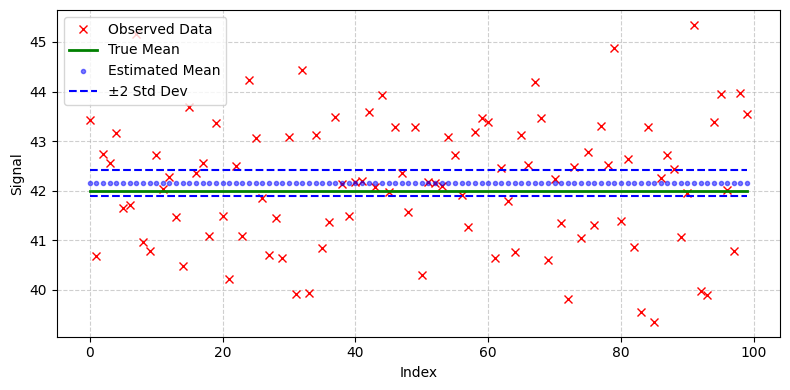

In [7]:
plt.figure(figsize=(8, 4))

plt.plot(DATA, "rx", label="Observed Data")
plt.plot([MU_TRUTH] * N, color="green", linewidth=2, label="True Mean")
plt.plot([m] * N, ".b", linewidth=1, label="Estimated Mean", alpha=0.5)
plt.plot([m + 2*np.sqrt(v)] * N, "b--", linewidth=1.5, label="±2 Std Dev")
plt.plot([m - 2*np.sqrt(v)] * N, "b--", linewidth=1.5)

plt.xlabel("Index")
plt.ylabel("Signal")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()


Other things to try would include:

 - Reducing the variance of the priors, i.e. make them informative. This will cause the inferred values to move closer to the
   prior values because we are now claiming we have prior knowledge of what $\mu$ and $\beta$ must be, and this can to some
   extent override the information in the data.
   
 - Changing the initial values of $m$, $v$, $b$ and $c$ to verify that the iteration can still converge to the correct    
   solution.
 
 - Try modifying the ground truth values and verify that we still infer the correct solution.
 
 - Increasing the level of noise should cause the variance estimates in the parameters to go up
 - Reducing the number of data samples should also increase the variance estimates to go up since we have less information to go on.
 

### Simple implementation of analytic Variational Bayes to infer a nonlinear forward model (optional)


This implements section 4 of the FMRIB Variational Bayes tutorial 1
for a single exponential decay model

$g(\theta)=A\exp^{-\lambda t}$

In [8]:
import numpy as np

This starts the random number generator off with the same seed value each time, so the results are repeatable. However it is worth changing the seed (or simply removing this line) to see how different data samples affect the results

In [9]:
np.random.seed(0)

In [10]:
# Ground truth parameters
A_TRUTH = 42
LAM_TRUTH = 1.5
NOISE_PREC_TRUTH = 1
NOISE_VAR_TRUTH = 1/NOISE_PREC_TRUTH
NOISE_STD_TRUTH = np.sqrt(NOISE_VAR_TRUTH)

Observed data samples are generated by Numpy from the ground truth Gaussian distribution. Reducing the number of samples should make the inference less 'confident' - i.e. the output variances for MU and BETA will increase

In [11]:
def model(t, a, lam):
    """
    Simple exponential decay model
    """
    return a * np.exp(-lam * t)


N = 100
DT = 0.05
t = np.array([float(t)*DT for t in range(N)])
DATA_CLEAN = model(t, A_TRUTH, LAM_TRUTH)
DATA_NOISY = DATA_CLEAN + np.random.normal(0, NOISE_STD_TRUTH, [N])

Let's look at the generated data

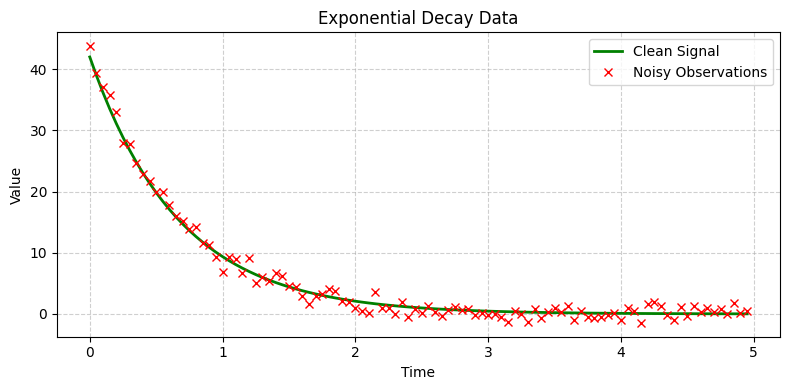

In [12]:
plt.figure(figsize=(8, 4))

plt.plot(t, DATA_CLEAN, color="green", linewidth=2, label="Clean Signal")
plt.plot(t, DATA_NOISY, "rx", label="Noisy Observations")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Exponential Decay Data")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

Priors - noninformative because of high variance

Note that the noise posterior is a gamma distribution with shape and scale parameters $s, c$. The mean here is $bc$ and the variance is $cb^2$. To make this more intuitive we define a prior mean and variance for the noise parameter BETA and express the prior scale and shape parameters in terms of these.

So long as the priors stay noninformative they should not have a big impact on the inferred values - this is the point of noninformative priors. However if you start to reduce the prior variances the inferred values will be drawn towards the prior values and away from the values suggested by the data.

In [13]:
a0 = 1.0
a_var0 = 1000
lam0 = 1.0
lam_var0 = 1.0

beta_mean0 = 1
beta_var0 = 1000
# c=scale, s=shape parameters for Gamma distribution
c0 = beta_var0 / beta_mean0
s0 = beta_mean0**2 / beta_var0

# Priors as vectors/matrices - M=means, C=covariance, P=precision
M0 = np.array([a0, lam0])
C0 = np.array([[a_var0, 0], [0, lam_var0]])
P0 = np.linalg.inv(C0)

In [14]:
def calc_jacobian(M):
    """
    Numerical differentiation to calculate Jacobian matrix
    of partial derivatives of model prediction with respect to
    parameters
    """
    J = None
    for param_idx, param_value in enumerate(M):
        ML = np.array(M)
        MU = np.array(M)
        delta = param_value * 1e-5
        if delta < 0:
            delta = -delta
        if delta < 1e-10:
            delta = 1e-10
            
        MU[param_idx] += delta
        ML[param_idx] -= delta
        
        YU = model(t, MU[0], MU[1])
        YL = model(t, ML[0], ML[1])
        if J is None:
            J = np.zeros([len(YU), len(M)], dtype=np.float32)
        J[:, param_idx] = (YU - YL) / (2*delta)
    return J

In [15]:
def update_model_params(k, M, P, s, c, J):
    """
    Update model parameters

    From section 4.2 of the FMRIB Variational Bayes Tutorial I
    
    k = data - prediction
    M = means (prior = M0)
    P = precision (prior=P0)
    s = noise shape (prior = s0)
    c = noise scale (prior = c0)
    J = Jacobian
    """
    P_new = s*c*np.dot(J.transpose(), J) + P0
    C_new = np.linalg.inv(P_new)
    M_new = np.dot(C_new, (s * c * np.dot(J.transpose(), (k + np.dot(J, M))) + np.dot(P0, M0)))
    return M_new, P_new

In [16]:
def update_noise(k, P, J):
    """
    Update noise parameters

    From section 4.2 of the FMRIB Variational Bayes Tutorial I
    
    k = data - prediction
    P = precision (prior=P0)
    J = Jacobian
    """
    C = np.linalg.inv(P)
    c_new = N/2 + c0
    s_new = 1/(1/s0 + 1/2 * np.dot(k.transpose(), k) + 1/2 * np.trace(np.dot(C, np.dot(J.transpose(), J))))
    return c_new, s_new

In [17]:
# Initial posterior parameters
M = np.array([1.0, 1.0])
C = np.array([[1.0, 0], [0.0, 1.0]])
P = np.linalg.inv(C)
c = 1e-8
s = 50.0
print("Iteration 0: A=%f, lam=%f, noise=%f" % (M[0], M[1], c*s))


Iteration 0: A=1.000000, lam=1.000000, noise=0.000000


In [18]:
for idx in range(20):
    k = DATA_NOISY - model(t, M[0], M[1])
    J = calc_jacobian(M)
    M, P = update_model_params(k, M, P, s, c, J)
    c, s = update_noise(k, P, J)
    print("Iteration %i: A=%f, lam=%f, noise=%f" % (idx+1, M[0], M[1], c*s))


Iteration 1: A=1.176446, lam=0.999936, noise=0.083571
Iteration 2: A=36.362580, lam=3.940429, noise=0.144227
Iteration 3: A=38.611770, lam=-1.479434, noise=0.335123
Iteration 4: A=0.014572, lam=-1.479356, noise=0.000000
Iteration 5: A=0.168731, lam=0.999980, noise=0.000177
Iteration 6: A=22.958324, lam=0.999409, noise=0.110871
Iteration 7: A=41.761112, lam=1.645034, noise=0.502966
Iteration 8: A=43.394219, lam=1.518467, noise=0.964637
Iteration 9: A=43.484554, lam=1.534200, noise=1.002382
Iteration 10: A=43.482396, lam=1.534064, noise=1.002647
Iteration 11: A=43.482422, lam=1.534066, noise=1.002647
Iteration 12: A=43.482457, lam=1.534067, noise=1.002647
Iteration 13: A=43.482429, lam=1.534066, noise=1.002647
Iteration 14: A=43.482450, lam=1.534067, noise=1.002647
Iteration 15: A=43.482427, lam=1.534066, noise=1.002647
Iteration 16: A=43.482417, lam=1.534066, noise=1.002647
Iteration 17: A=43.482415, lam=1.534065, noise=1.002647
Iteration 18: A=43.482403, lam=1.534065, noise=1.002647
It

We can use the estimated parameters to predict the signal and plot the data

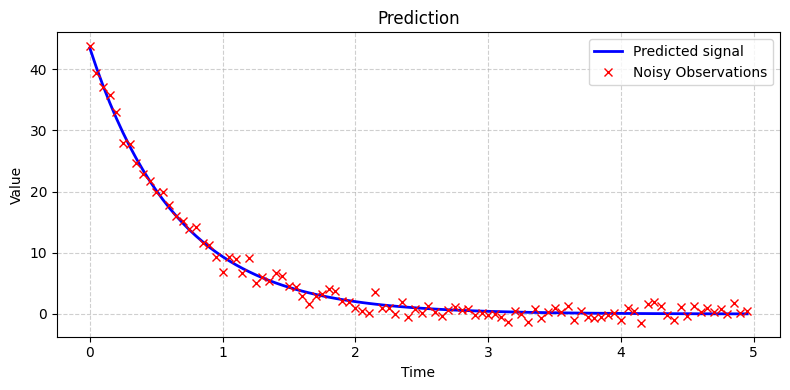

In [19]:
predicted = model(t, M[0], M[1])

plt.figure(figsize=(8, 4))

plt.plot(t, predicted, color="blue", linewidth=2, label="Predicted signal")
plt.plot(t, DATA_NOISY, "rx", label="Noisy Observations")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Prediction")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()